ĐỒ ÁN MẠNG XÃ HỘI - **cần thêm trực quan hoá, tiền xử lí dữ liệu lại, check lại hiệu suất, thêm các đặc trưng **

#  Cài đặt

In [ ]:
!pip install networkx node2vec

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4


In [ ]:
!pip install --upgrade pandas scipy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 12.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.2 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [ ]:
!pip install torch torch-geometric networkx pandas

# Tiền xử lý dữ liệu

In [ ]:
#1. Cài đặt, import các gói thư viện pandas
from google.colab import drive
import pandas as pd
import numpy as np

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Đọc file .txt với separator tab (\t)
file_path = '/content/drive/MyDrive/Colab Notebooks/BIOGRID-CORONAVIRUS-4.4.242.tab3.txt'

# Đọc file .txt vào DataFrame
df = pd.read_csv(file_path, sep='\t')

# Xem thông tin của DataFrame
print(df.head())

# Lưu DataFrame vào file CSV
df.to_csv('BIOGRID_Coronavirus.csv', index=False)

   #BioGRID Interaction ID Entrez Gene Interactor A Entrez Gene Interactor B  \
0                   141211                   850980                   852501   
1                   141212                   852501                   850980   
2                   141213                   850980                   856680   
3                   141214                   856680                   850980   
4                   141215                   852501                   850793   

   BioGRID ID Interactor A  BioGRID ID Interactor B  \
0                    31542                    32899   
1                    32899                    31542   
2                    31542                    36697   
3                    36697                    31542   
4                    32899                    31376   

  Systematic Name Interactor A Systematic Name Interactor B  \
0                      YLR274W                      YBR202W   
1                      YBR202W                      YLR274W   

In [ ]:
df.head()

,#BioGRID Interaction ID,Entrez Gene Interactor A,Entrez Gene Interactor B,BioGRID ID Interactor A,BioGRID ID Interactor B,Systematic Name Interactor A,Systematic Name Interactor B,Official Symbol Interactor A,Official Symbol Interactor B,Synonyms Interactor A,...,TREMBL Accessions Interactor B,REFSEQ Accessions Interactor B,Ontology Term IDs,Ontology Term Names,Ontology Term Categories,Ontology Term Qualifier IDs,Ontology Term Qualifier Names,Ontology Term Types,Organism Name Interactor A,Organism Name Interactor B
0,141211,850980,852501,31542,32899,YLR274W,YBR202W,MCM5,MCM7,BOB1|CDC46|MCM DNA helicase complex subunit MC...,...,-,NP_009761,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)
1,141212,852501,850980,32899,31542,YBR202W,YLR274W,MCM7,MCM5,CDC47|MCM DNA helicase complex subunit MCM7|L0...,...,-,NP_013376,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)
2,141213,850980,856680,31542,36697,YLR274W,YEL032W,MCM5,MCM3,BOB1|CDC46|MCM DNA helicase complex subunit MC...,...,-,NP_010882,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)
3,141214,856680,850980,36697,31542,YEL032W,YLR274W,MCM3,MCM5,MCM DNA helicase complex subunit MCM3|L000001039,...,-,NP_013376,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)
4,141215,852501,850793,32899,31376,YBR202W,YLR103C,MCM7,CDC45,CDC47|MCM DNA helicase complex subunit MCM7|L0...,...,-,NP_013204,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)


In [ ]:
print(df.dtypes)

#BioGRID Interaction ID                int64
Entrez Gene Interactor A              object
Entrez Gene Interactor B              object
BioGRID ID Interactor A                int64
BioGRID ID Interactor B                int64
Systematic Name Interactor A          object
Systematic Name Interactor B          object
Official Symbol Interactor A          object
Official Symbol Interactor B          object
Synonyms Interactor A                 object
Synonyms Interactor B                 object
Experimental System                   object
Experimental System Type              object
Author                                object
Publication Source                    object
Organism ID Interactor A               int64
Organism ID Interactor B               int64
Throughput                            object
Score                                 object
Modification                          object
Qualifications                        object
Tags                                  object
Source Dat

In [ ]:
print(df.isnull().sum())

#BioGRID Interaction ID                0
Entrez Gene Interactor A               0
Entrez Gene Interactor B               0
BioGRID ID Interactor A                0
BioGRID ID Interactor B                0
Systematic Name Interactor A           0
Systematic Name Interactor B           0
Official Symbol Interactor A           0
Official Symbol Interactor B           0
Synonyms Interactor A                  0
Synonyms Interactor B                  0
Experimental System                    0
Experimental System Type               0
Author                                 0
Publication Source                     0
Organism ID Interactor A               0
Organism ID Interactor B               0
Throughput                             0
Score                                  0
Modification                           0
Qualifications                         0
Tags                                   0
Source Database                        0
SWISS-PROT Accessions Interactor A     0
TREMBL Accession

In [ ]:
print(f"Số dòng trước khi xoá: {len(df)}")

Số dòng trước khi xoá: 68474


In [ ]:
# Giữ lại các cột cần thiết
df = df[["BioGRID ID Interactor A", "BioGRID ID Interactor B",
                  "Official Symbol Interactor A", "Official Symbol Interactor B",
                  "Experimental System"]]

# Kiểm tra kết quả
print(f"Số dòng sau khi xoá các cột không cần thiết: {len(df)}")

# Lưu dataframe đã sạch vào file mới (tuỳ chọn)
df.to_csv('BIOGRID_Cleaned_Columns.csv', index=False)

# Xem qua vài dòng dữ liệu đã sạch
print(df.head())

Số dòng sau khi xoá các cột không cần thiết: 68474
   BioGRID ID Interactor A  BioGRID ID Interactor B  \
0                    31542                    32899   
1                    32899                    31542   
2                    31542                    36697   
3                    36697                    31542   
4                    32899                    31376   

  Official Symbol Interactor A Official Symbol Interactor B  \
0                         MCM5                         MCM7   
1                         MCM7                         MCM5   
2                         MCM5                         MCM3   
3                         MCM3                         MCM5   
4                         MCM7                        CDC45   

  Experimental System  
0          Two-hybrid  
1          Two-hybrid  
2          Two-hybrid  
3          Two-hybrid  
4          Two-hybrid  


In [ ]:
# Thay thế tất cả giá trị "-" bằng NaN
df.replace("-", np.nan, inplace=True)

# Xoá các hàng có bất kỳ giá trị NaN nào
df = df.dropna()

In [ ]:
print(f"Số dòng sau khi xoá: {len(df)}")

Số dòng sau khi xoá: 68474


In [ ]:
print(df.head())

   BioGRID ID Interactor A  BioGRID ID Interactor B  \
0                    31542                    32899   
1                    32899                    31542   
2                    31542                    36697   
3                    36697                    31542   
4                    32899                    31376   

  Official Symbol Interactor A Official Symbol Interactor B  \
0                         MCM5                         MCM7   
1                         MCM7                         MCM5   
2                         MCM5                         MCM3   
3                         MCM3                         MCM5   
4                         MCM7                        CDC45   

  Experimental System  
0          Two-hybrid  
1          Two-hybrid  
2          Two-hybrid  
3          Two-hybrid  
4          Two-hybrid  


# Xây dựng đồ thị

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
# Xác định nodes (Protein ID & Symbol)
nodes = pd.concat([df[["BioGRID ID Interactor A", "Official Symbol Interactor A"]],
                   df[["BioGRID ID Interactor B", "Official Symbol Interactor B"]]])
nodes = nodes.rename(columns={"BioGRID ID Interactor A": "ID", "Official Symbol Interactor A": "Protein"})
nodes = nodes.rename(columns={"BioGRID ID Interactor B": "ID", "Official Symbol Interactor B": "Protein"})
nodes = nodes.drop_duplicates().reset_index(drop=True)
# Xác định edges (Tương tác giữa protein)
edges = df[["BioGRID ID Interactor A", "BioGRID ID Interactor B"]].drop_duplicates()

# ========================== 2. Xây dựng đồ thị NetworkX ==========================
G = nx.Graph()
G.add_edges_from(edges.values)

In [ ]:
# Loại bỏ các cột trùng lặp (chỉ giữ lại một bộ ID - Protein)
nodes = nodes.loc[:, ~nodes.columns.duplicated()]
print(nodes.head())  # Kiểm tra lại dữ liệu sau khi xử lý

         ID Protein
0   31542.0    MCM5
1   32899.0    MCM7
2   36697.0    MCM3
3   34611.0    RUD3
4  107067.0   CCND1


In [ ]:
print("Sample node in Graph:", list(G.nodes)[:5])
print("Type of node in Graph:", type(list(G.nodes)[0]))

Sample node in Graph: [31542, 32899, 36697, 31376, 34611]
Type of node in Graph: <class 'numpy.int64'>


In [ ]:
print(nodes["ID"].isna().sum())  # Số lượng NaN
print((nodes["ID"] == float("inf")).sum())  # Số lượng inf
print((nodes["ID"] == float("-inf")).sum())  # Số lượng -inf

8451
0
0


In [ ]:
nodes = nodes.dropna(subset=["ID"])

In [ ]:
nodes["ID"] = nodes["ID"].astype(int)

In [ ]:
# Tạo dictionary ánh xạ từ Node ID sang Protein Name
node_info = dict(zip(nodes["ID"], nodes["Protein"]))

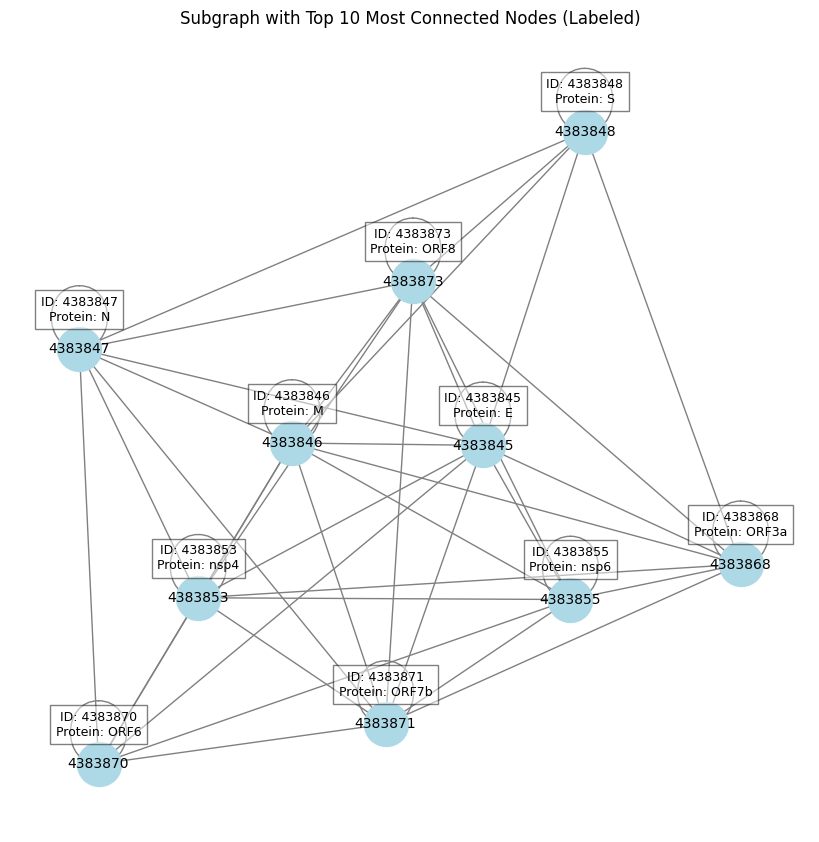

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Chọn 10 node có nhiều liên kết nhất
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:10]
subgraph_nodes = [node for node, _ in top_nodes]
subgraph = G.subgraph(subgraph_nodes)  # Tạo subgraph

# Vẽ đồ thị với layout tối ưu liên kết
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(subgraph, seed=42)  # Giữ node có nhiều liên kết gần nhau
nx.draw(subgraph, pos, with_labels=True, node_size=1000, node_color="lightblue", font_size=10, edge_color="gray")

# Đẩy thuộc tính ra xa khỏi node
offset = 0.08  # Điều chỉnh khoảng cách giữa node và text
for node, (x, y) in pos.items():
    protein_name = node_info.get(node, "Unknown")  # Lấy Protein Name từ dictionary
    text = f"ID: {node}\nProtein: {protein_name}"  # Hiển thị cả ID và Protein Name
    plt.text(x, y + offset, text, fontsize=9, ha='center', bbox=dict(facecolor="white", alpha=0.5))

plt.title("Subgraph with Top 10 Most Connected Nodes (Labeled)")
plt.show()

In [ ]:
# Số lượng nodes (đỉnh)
num_nodes = G.number_of_nodes()
print(f"Số lượng nodes: {num_nodes}")

# Số lượng edges (cạnh)
num_edges = G.number_of_edges()
print(f"Số lượng edges: {num_edges}")

Số lượng nodes: 8564
Số lượng edges: 49017


# Trích xuất các đặc trưng


**Degree Centrality + Clustering Coefficient (cần thêm 2 nữa hay sao á)**

In [ ]:
import torch
from node2vec import Node2Vec
import networkx as nx

# Tạo đặc trưng Degree Centrality & Clustering Coefficient
node_features = {node: [nx.degree_centrality(G)[node], nx.clustering(G, node)] for node in G.nodes()}
node_features_tensor = torch.tensor([node_features[node] for node in G.nodes()], dtype=torch.float)

# Huấn luyện Node2Vec
node2vec = Node2Vec(G, dimensions=16, walk_length=10, num_walks=50, workers=1)
model = node2vec.fit(window=5, min_count=1, batch_words=2)

# Chuyển embeddings thành tensor (giữ dạng dense)
node_embeddings = torch.tensor([model.wv[str(node)] for node in G.nodes()], dtype=torch.float)

# Kết hợp đặc trưng
X = torch.cat([node_features_tensor, node_embeddings], dim=1)

print("Kích thước X:", X.shape)  # Kiểm tra kết quả


Computing transition probabilities:   0%|          | 0/8564 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 50/50 [04:16<00:00,  5.13s/it]


Kích thước X: torch.Size([8564, 18])


<ipython-input-27-6c43b4247b2a>:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  node_embeddings = torch.tensor([model.wv[str(node)] for node in G.nodes()], dtype=torch.float)


In [ ]:
# 4. Chuyển dữ liệu sang PyG format ==========================
# Mapping node IDs to indices
node_idx_mapping = {node: i for i, node in enumerate(G.nodes())}
edge_index = torch.tensor([[node_idx_mapping[e[0]], node_idx_mapping[e[1]]] for e in edges.values], dtype=torch.long).t()

# Tạo tập dữ liệu PyG
data = Data(x=X, edge_index=edge_index)

In [ ]:
# 5. Chuẩn bị tập train/test ==========================
# Chia tập train-test 80-20%
from sklearn.model_selection import train_test_split
edges_train, edges_test = train_test_split(edges.values, test_size=0.2, random_state=42)

# Chuyển edges_test thành tensor
edge_index_train = torch.tensor([[node_idx_mapping[e[0]], node_idx_mapping[e[1]]] for e in edges_train], dtype=torch.long).t()
edge_index_test = torch.tensor([[node_idx_mapping[e[0]], node_idx_mapping[e[1]]] for e in edges_test], dtype=torch.long).t()

# Áp dụng GCN

In [ ]:
# 6. Xây dựng mô hình GCN ==========================
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import GCNConv

class GCNLinkPredictor(nn.Module):
    def __init__(self, input_dim):
        super(GCNLinkPredictor, self).__init__()
        self.conv1 = GCNConv(input_dim, 64)
        self.conv2 = GCNConv(64, 32)
        self.fc = nn.Linear(32, 1)

    def forward(self, x, edge_index):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        return x

# Khởi tạo mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCNLinkPredictor(X.shape[1]).to(device)
data = data.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
import torch
import torch.nn.functional as F

def train():
    model.train()
    optimizer.zero_grad()

    node_embeddings = model(data.x, data.edge_index)

    # Positive edges (cạnh có trong đồ thị)
    src_pos, dst_pos = edge_index_train
    pos_scores = (node_embeddings[src_pos] * node_embeddings[dst_pos]).sum(dim=1)

    # Negative edges (cạnh không tồn tại)
    neg_src = torch.randint(0, data.num_nodes, (len(src_pos),)).to(device)
    neg_dst = torch.randint(0, data.num_nodes, (len(dst_pos),)).to(device)
    neg_scores = (node_embeddings[neg_src] * node_embeddings[neg_dst]).sum(dim=1)

    # Gộp cả cạnh dương và cạnh âm
    scores = torch.cat([pos_scores, neg_scores])
    labels = torch.cat([torch.ones(len(pos_scores)), torch.zeros(len(neg_scores))]).to(device)

    loss = criterion(scores, labels)
    loss.backward()
    optimizer.step()

    return loss.item()

In [ ]:
def evaluate():
    model.eval()
    with torch.no_grad():
        node_embeddings = model(data.x, data.edge_index)

        # Positive edges (cạnh tồn tại)
        src_pos, dst_pos = edge_index_test
        pos_scores = (node_embeddings[src_pos] * node_embeddings[dst_pos]).sum(dim=1)

        # Negative edges (cạnh không tồn tại)
        neg_src = torch.randint(0, data.num_nodes, (len(src_pos),)).to(device)
        neg_dst = torch.randint(0, data.num_nodes, (len(dst_pos),)).to(device)
        neg_scores = (node_embeddings[neg_src] * node_embeddings[neg_dst]).sum(dim=1)

        # Gộp cả cạnh dương và âm
        scores = torch.cat([pos_scores, neg_scores]).cpu().numpy()
        labels = torch.cat([torch.ones(len(pos_scores)), torch.zeros(len(neg_scores))]).cpu().numpy()

        # Tính AUC
        auc = roc_auc_score(labels, scores)
    return auc

In [ ]:
#9. Chạy mô hình ==========================
from sklearn.metrics import roc_auc_score

num_epochs = 50
losses = []
aucs = []

for epoch in range(num_epochs):
    loss = train()
    auc = evaluate()

    losses.append(loss)
    aucs.append(auc)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}, AUC: {auc:.4f}")

Epoch 1/50, Loss: 0.6412, AUC: 0.8461
Epoch 2/50, Loss: 0.6365, AUC: 0.8484
Epoch 3/50, Loss: 0.6350, AUC: 0.8512
Epoch 4/50, Loss: 0.6320, AUC: 0.8563
Epoch 5/50, Loss: 0.6302, AUC: 0.8605
Epoch 6/50, Loss: 0.6279, AUC: 0.8629
Epoch 7/50, Loss: 0.6265, AUC: 0.8646
Epoch 8/50, Loss: 0.6237, AUC: 0.8712
Epoch 9/50, Loss: 0.6225, AUC: 0.8712
Epoch 10/50, Loss: 0.6214, AUC: 0.8726
Epoch 11/50, Loss: 0.6196, AUC: 0.8729
Epoch 12/50, Loss: 0.6194, AUC: 0.8759
Epoch 13/50, Loss: 0.6171, AUC: 0.8777
Epoch 14/50, Loss: 0.6175, AUC: 0.8773
Epoch 15/50, Loss: 0.6154, AUC: 0.8807
Epoch 16/50, Loss: 0.6138, AUC: 0.8816
Epoch 17/50, Loss: 0.6135, AUC: 0.8848
Epoch 18/50, Loss: 0.6116, AUC: 0.8843
Epoch 19/50, Loss: 0.6104, AUC: 0.8847
Epoch 20/50, Loss: 0.6086, AUC: 0.8874
Epoch 21/50, Loss: 0.6085, AUC: 0.8851
Epoch 22/50, Loss: 0.6077, AUC: 0.8894
Epoch 23/50, Loss: 0.6066, AUC: 0.8854
Epoch 24/50, Loss: 0.6051, AUC: 0.8845
Epoch 25/50, Loss: 0.6059, AUC: 0.8886
Epoch 26/50, Loss: 0.6050, AUC: 0.

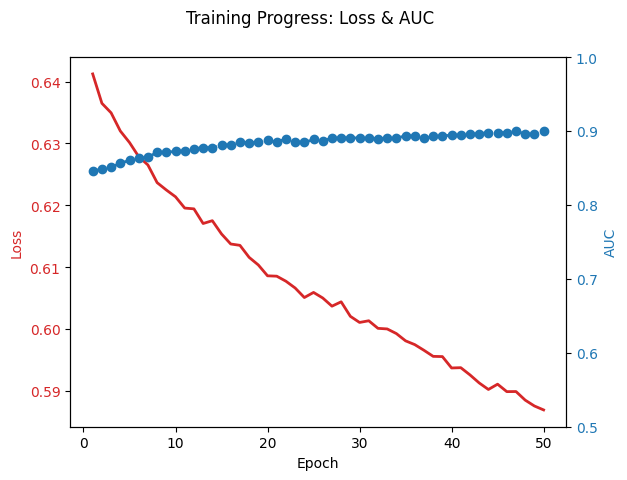

In [ ]:
import matplotlib.pyplot as plt

# Trực quan hóa Loss & AUC
fig, ax1 = plt.subplots()

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color="tab:red")
ax1.plot(range(1, num_epochs + 1), losses, color="tab:red", label="Loss", linewidth=2)
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.set_ylabel("AUC", color="tab:blue")
ax2.plot(range(1, num_epochs + 1), aucs, color="tab:blue", linestyle="dashed", linewidth=2, marker="o")
ax2.tick_params(axis="y", labelcolor="tab:blue")
ax2.set_ylim(0.5, 1)  # Giới hạn AUC trong khoảng 0.5 - 1 để dễ nhìn thấy

fig.suptitle("Training Progress: Loss & AUC")
plt.show()


Loss giảm dần qua từng epoch.
AUC tăng lên và ổn định ở giá trị cao (>0.8).
-> Mô hình khá ổn nhưng có thể cải thiện.